# Step 3 — Predictor Evaluation

**Goal:** Evaluate the DNN predictor **independently of RL** before plugging it into the loop.
If the predictor is bad, the precedence gate will hurt rather than help — so we validate it thoroughly here.

---

### Three evaluation axes

| # | Method | What it reveals |
|---|---|---|
| 1 | **Per-dim MSE on test set** | Which state dimensions are hardest to predict |
| 2 | **Multi-step rollout accuracy** | How quickly prediction error compounds over k steps |
| 3 | **Residual plots** | Systematic bias in specific state regions |

### Stop criterion

> If **val MSE > 2 × train MSE** → the model is overfitting → go back to Step 2 and add dropout or reduce hidden size before proceeding to Step 4.

### Why evaluate before the RL loop?

The predictor is used as a **frozen oracle** in Step 4. If it has systematic bias in certain
state regions (e.g. it underestimates angular velocity when the pole is leaning far),
the RL agent will receive wrong signals in exactly those critical states.
Catching this here is much cheaper than debugging it inside the RL training loop.

### Files needed
```
predictor.pth          ← model weights (best approach from Step 2)
predictor_config.pt    ← approach flags: is_delta, is_probabilistic, hidden, etc.
norm_stats.npz         ← mean and std from train set
cartpole_data_dqn.npz  ← dataset (we use the test split only here)
```

---
## Cell 1 — Imports and device

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import gymnasium as gym
import warnings
warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")

DIM_LABELS = ["x (position)", "ẋ (velocity)", "θ (angle)", "θ̇ (ang. vel)"]

Device : cpu


---
## Cell 2 — Re-define model classes

We copy the model definitions from Step 2 so this notebook is self-contained.
The architecture must match exactly what was used during training — otherwise
`load_state_dict` will throw a shape mismatch error.

In [3]:
class DeterministicPredictor(nn.Module):
    """3-layer MLP: [state(4) | one-hot action(2)] → predicted Δs (4)."""
    def __init__(self, input_dim=6, hidden=256, output_dim=4, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden),    nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, output_dim),
        )

    def forward(self, state, action_oh):
        return self.net(torch.cat([state, action_oh], dim=-1))


print("Model class defined for Approach B (delta predictor).")

Model class defined for Approach B (delta predictor).


---
## Cell 3 — Load predictor, config, and normalization stats

We load:
- `predictor_config.pt` → contains hyperparameters for the Approach B delta predictor
- `predictor.pth` → the trained weights
- `norm_stats.npz` → mean and std (computed on train set in Step 1)

The predictor is set to `.eval()` and will **never be updated** in this notebook.
We also disable dropout by calling `.eval()` — Dropout only activates during training.

In [4]:
# ── Load config ──────────────────────────────────────────────────────────────
config = torch.load("dnn predictor/predictor_config.pt", map_location=DEVICE)
print("Predictor config:")
for k, v in config.items():
    print(f"  {k:22s}: {v}")

assert config["is_delta"], "Expected Approach B (delta predictor)"
HIDDEN     = config["hidden"]
INPUT_DIM  = config["input_dim"]          # 6
OUTPUT_DIM = config["output_dim"]         # 4

predictor = DeterministicPredictor(INPUT_DIM, HIDDEN, OUTPUT_DIM).to(DEVICE)

predictor.load_state_dict(torch.load("dnn predictor/predictor.pth", map_location=DEVICE))
predictor.eval()   # disables Dropout — critical for deterministic evaluation
print(f"\nPredictor loaded: {predictor.__class__.__name__}  (Approach B) ")
print(f"Parameters      : {sum(p.numel() for p in predictor.parameters()):,}")

# ── Normalization stats ───────────────────────────────────────────────────────
stats = np.load("dnn predictor/norm_stats.npz")
MEAN  = torch.tensor(stats["mean"], dtype=torch.float32).to(DEVICE)   # (1, 4)
STD   = torch.tensor(stats["std"],  dtype=torch.float32).to(DEVICE)   # (1, 4)
print(f"\nNormalization mean : {MEAN.cpu().numpy().flatten().round(4)}")
print(f"Normalization std  : {STD.cpu().numpy().flatten().round(4)}")

Predictor config:
  approach              : B
  is_delta              : True
  is_probabilistic      : False
  input_dim             : 6
  hidden                : 256
  output_dim            : 4
  obs_dim               : 4
  act_dim               : 2

Predictor loaded: DeterministicPredictor  (Approach B) 
Parameters      : 68,612

Normalization mean : [ 0.1619  0.012  -0.0048 -0.0125]
Normalization std  : [0.9088 0.8651 0.0752 0.4126]


---
## Cell 4 — Load the test set

We use **only the test split** — data the predictor has never seen during training or validation.
This is the honest estimate of real-world performance.

We also compute the train and val MSE for the **stop criterion** check:
> val MSE > 2 × train MSE → overfitting → go back to Step 2.

In [5]:
data = np.load("cartpole_data_mixed_policy.npz")

def to_tensor(key):
    return torch.tensor(data[key], dtype=torch.float32)

# All three splits — needed for the stop-criterion check
s_train  = to_tensor("s_train");  a_train  = to_tensor("a_train");  sn_train = to_tensor("sn_train")
s_val    = to_tensor("s_val");    a_val    = to_tensor("a_val");    sn_val   = to_tensor("sn_val")
s_test   = to_tensor("s_test");   a_test   = to_tensor("a_test");   sn_test  = to_tensor("sn_test")

print("Splits loaded:")
print(f"  train : {s_train.shape[0]:,} transitions")
print(f"  val   : {s_val.shape[0]:,} transitions")
print(f"  test  : {s_test.shape[0]:,} transitions  ← used for all evaluations below")

Splits loaded:
  train : 70,000 transitions
  val   : 10,000 transitions
  test  : 20,000 transitions  ← used for all evaluations below


---
## Cell 5 — Prediction helper

One function that handles the Approach B predictor:
- **Approach B** (delta): `ŝ_{t+1} = s_t + model(s_t, a_t)`

This function always returns the reconstructed next state in **normalized space**.

In [6]:
@torch.no_grad()
def predict(s: torch.Tensor, a: torch.Tensor) -> torch.Tensor:
    """
    Run the Approach B predictor on a batch of (state, action) pairs.

    Parameters
    ----------
    s : (N, 4) normalized states
    a : (N, 2) one-hot actions

    Returns
    -------
    sn_pred : (N, 4) predicted next state in normalized space
    """
    s_d, a_d = s.to(DEVICE), a.to(DEVICE)
    out     = predictor(s_d, a_d)
    sn_pred = s + out.cpu()  # Approach B predicts Δs
    return sn_pred


# Quick sanity check on 5 samples
sn_pred_sample = predict(s_test[:5], a_test[:5])
print("Sanity check — first 5 test predictions:")
print(f"  s_test[0]   : {s_test[0].numpy().round(4)}")
print(f"  sn_pred[0]  : {sn_pred_sample[0].numpy().round(4)}")
print(f"  sn_true[0]  : {sn_test[0].numpy().round(4)}")
print(f"\n  Approach      : B (delta predictor)")

Sanity check — first 5 test predictions:
  s_test[0]   : [-0.2419  0.4098 -0.6342 -2.3894]
  sn_pred[0]  : [-0.2337  0.1857 -0.8967 -1.7212]
  sn_true[0]  : [-0.2338  0.1851 -0.8997 -1.7211]

  Approach      : B (delta predictor)


---
## Cell 6 — Stop criterion: overfitting check

Before any analysis, we check the stop criterion:

> **val MSE > 2 × train MSE → go back to Step 2**

We compute MSE on all three splits and print the ratio.

**Why this ratio?**  
Some gap between train and val is always expected — the model was fit on train data.
A ratio below 2 means the model generalizes well enough for deployment in the RL loop.
A ratio above 2 means the model has memorized training patterns and will degrade
on the distribution the RL agent actually visits.

In [10]:
def compute_mse_split(s, a, sn_true):
    """Compute total MSE (scalar) and per-dim MSE (4,) for one split."""
    sn_pred = predict(s, a)
    sq_err     = (sn_pred - sn_true) ** 2          # (N, 4)
    per_dim    = sq_err.mean(dim=0).numpy()         # (4,)
    total      = sq_err.mean().item()
    return total, per_dim


mse_train, pd_train = compute_mse_split(s_train, a_train, sn_train)
mse_val,   pd_val   = compute_mse_split(s_val,   a_val,   sn_val)
mse_test,  pd_test  = compute_mse_split(s_test,  a_test,  sn_test)

overfit_ratio = mse_val / (mse_train + 1e-10)
STOP = overfit_ratio > 2.0

print("=" * 60)
print("STOP CRITERION CHECK")
print("=" * 60)
print(f"  Train MSE : {mse_train:.6f}")
print(f"  Val   MSE : {mse_val:.6f}")
print(f"  Test  MSE : {mse_test:.6f}")
print(f"  Val/Train ratio : {overfit_ratio:.3f}  (threshold: 2.0)")
print()
if STOP:
    print("  ⛔  STOP — val MSE > 2× train MSE.")
    print("      The model is overfitting. Go back to Step 2 and:")
    print("        • Increase dropout (e.g. 0.1 → 0.3)")
    print("        • Reduce hidden size (e.g. 256 → 128)")
    print("        • Reduce n_epochs or use early stopping")
else:
    print("  ✅  OK — model generalizes well. Proceed with evaluation.")

print()
print("Per-dimension MSE on test set:")
print(f"  {'Dimension':20s}  {'Train':>10}  {'Val':>10}  {'Test':>10}")
print("  " + "-" * 56)
for i, name in enumerate(DIM_LABELS):
    print(f"  {name:20s}  {pd_train[i]:10.6f}  {pd_val[i]:10.6f}  {pd_test[i]:10.6f}")

STOP CRITERION CHECK
  Train MSE : 0.000002
  Val   MSE : 0.000002
  Test  MSE : 0.000002
  Val/Train ratio : 0.970  (threshold: 2.0)

  ✅  OK — model generalizes well. Proceed with evaluation.

Per-dimension MSE on test set:
  Dimension                  Train         Val        Test
  --------------------------------------------------------
  x (position)            0.000003    0.000003    0.000003
  ẋ (velocity)            0.000002    0.000001    0.000002
  θ (angle)               0.000002    0.000002    0.000002
  θ̇ (ang. vel)           0.000002    0.000002    0.000002


---
## Cell 7 — Evaluation 1: Per-dimension MSE bar chart

Visualize which state dimensions the predictor handles well and which it struggles with.

**What to expect for CartPole:**
- `x` (position) and `θ` (angle) should have **low MSE** — they change slowly.
- `ẋ` (cart velocity) and `θ̇` (angular velocity) may have **higher MSE** — they are
  directly affected by the force impulse and change more abruptly.

**Why this matters for Step 4:**  
If `θ̇` has very high MSE, the action gate based on angle velocity will be noisy.
In that case, prefer gating on `θ` (angle) which is more reliably predicted.

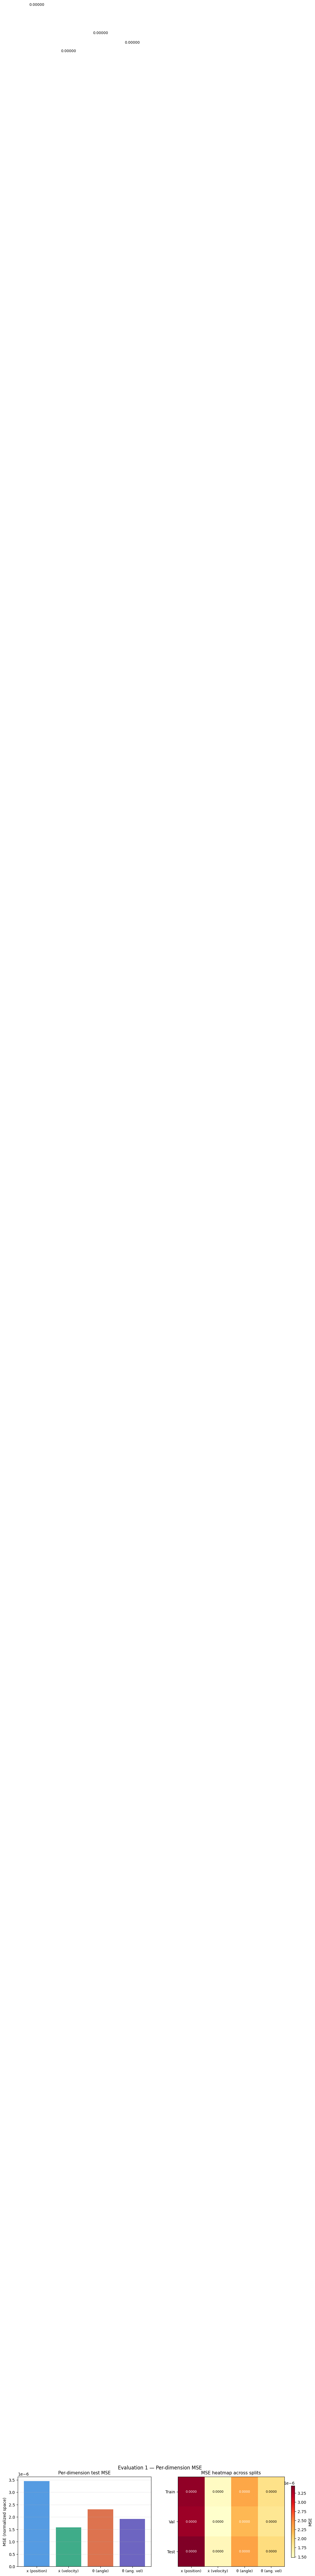

Hardest dimension to predict : x (position)  (MSE=0.000003)
Easiest dimension to predict : ẋ (velocity)   (MSE=0.000002)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: bar chart of per-dim test MSE ──────────────────────────────────────
ax = axes[0]
colors  = ["#378ADD", "#1D9E75", "#D85A30", "#534AB7"]
bars    = ax.bar(DIM_LABELS, pd_test, color=colors, alpha=0.85, edgecolor="none")

# Label each bar with its exact MSE value
for bar, mse in zip(bars, pd_test):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
            f"{mse:.5f}", ha="center", va="bottom", fontsize=9)

ax.set_ylabel("MSE (normalized space)")
ax.set_title("Per-dimension test MSE", fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.tick_params(axis="x", labelsize=9)

# ── Right: MSE heatmap across splits ─────────────────────────────────────────
ax2 = axes[1]
matrix = np.stack([pd_train, pd_val, pd_test])   # (3, 4)
im     = ax2.imshow(matrix, aspect="auto", cmap="YlOrRd")

ax2.set_xticks(range(4)); ax2.set_xticklabels(DIM_LABELS, fontsize=9)
ax2.set_yticks(range(3)); ax2.set_yticklabels(["Train", "Val", "Test"], fontsize=10)
ax2.set_title("MSE heatmap across splits", fontsize=11)
plt.colorbar(im, ax=ax2, shrink=0.8, label="MSE")

# Annotate cells
for r in range(3):
    for c in range(4):
        ax2.text(c, r, f"{matrix[r,c]:.4f}",
                 ha="center", va="center", fontsize=8,
                 color="white" if matrix[r,c] > matrix.max()*0.6 else "black")

plt.suptitle("Evaluation 1 — Per-dimension MSE", fontsize=12, fontweight="500")
plt.tight_layout()
plt.show()

worst_dim = DIM_LABELS[np.argmax(pd_test)]
best_dim  = DIM_LABELS[np.argmin(pd_test)]
print(f"Hardest dimension to predict : {worst_dim}  (MSE={pd_test.max():.6f})")
print(f"Easiest dimension to predict : {best_dim}   (MSE={pd_test.min():.6f})")

---
## Cell 8 — Evaluation 2: Rollout accuracy (multi-step prediction)

**What is rollout accuracy?**

Instead of predicting just one step ahead, we apply the DNN **k times in a row**,
feeding its own output back as the next input:

$$\hat{s}_1 = f(s_0, a_0), \quad \hat{s}_2 = f(\hat{s}_1, a_1), \quad \ldots, \quad \hat{s}_k = f(\hat{s}_{k-1}, a_{k-1})$$

**Why does this matter?**  
In the RL loop (Step 4), if we want to plan ahead or use the predictor for lookahead,
errors compound. A model that has 0.001 MSE at step 1 might have 0.05 MSE at step 10.
The **reliability horizon** is the number of steps after which error exceeds a threshold.

**How we compute it:**  
We take real CartPole episodes from the test buffer, apply the DNN k times on the
recorded action sequence, and measure MSE between the predicted trajectory and the
real trajectory at each step k.

In [ ]:
def rollout_accuracy(
    s0_batch:    torch.Tensor,   # (N, 4) initial normalized states
    a_seq:       torch.Tensor,   # (N, K, 2) sequence of K one-hot actions
    sn_true_seq: torch.Tensor,   # (N, K, 4) ground-truth next states at each step
    max_steps:   int = 20,
) -> np.ndarray:
    """
    Apply the predictor k=1..max_steps times and measure MSE at each step.

    Parameters
    ----------
    s0_batch    : starting states for each trajectory
    a_seq       : the exact sequence of actions taken (from real episodes)
    sn_true_seq : the ground-truth states produced by the environment

    Returns
    -------
    mse_curve : (max_steps, 4) — per-dim MSE at each rollout step
    """
    s_cur  = s0_batch.clone()                  # (N, 4) running state estimate
    errors = []                                 # list of (N, 4) squared errors

    for k in range(max_steps):
        a_k         = a_seq[:, k, :]            # (N, 2) action at step k
        sn_k_true   = sn_true_seq[:, k, :]     # (N, 4) ground truth at step k

        sn_pred, _  = predict(s_cur, a_k)      # (N, 4)

        sq_err = (sn_pred - sn_k_true) ** 2    # (N, 4)
        errors.append(sq_err.mean(dim=0).numpy())   # (4,)

        s_cur = sn_pred                         # feed prediction back as next input

    return np.stack(errors)   # (max_steps, 4)


# ── Build rollout sequences from real episodes ────────────────────────────────
# We collect N_TRAJ real episodes from CartPole and record states + actions

N_TRAJ    = 200    # number of trajectories
MAX_STEPS = 20     # max steps to roll out
env_eval  = gym.make("CartPole-v1")

s0_list, a_list, sn_list = [], [], []
valid_count = 0

for ep in range(N_TRAJ):
    obs, _ = env_eval.reset(seed=SEED + ep + 1000)
    ep_s, ep_a, ep_sn = [], [], []

    for _ in range(MAX_STEPS):
        action    = env_eval.action_space.sample()   # random actions for diversity
        next_obs, _, terminated, truncated, _ = env_eval.step(action)

        # Normalize obs to match DNN input space
        s_norm  = (torch.tensor(obs,      dtype=torch.float32).unsqueeze(0) - MEAN.cpu()) / STD.cpu()
        sn_norm = (torch.tensor(next_obs, dtype=torch.float32).unsqueeze(0) - MEAN.cpu()) / STD.cpu()
        a_oh    = torch.zeros(1, 2); a_oh[0, action] = 1.0

        ep_s.append(s_norm);  ep_a.append(a_oh);  ep_sn.append(sn_norm)

        obs = next_obs
        if terminated or truncated:
            break

    # Only use episodes that lasted the full MAX_STEPS
    if len(ep_s) == MAX_STEPS:
        s0_list.append(ep_s[0])
        a_list.append(torch.cat(ep_a, dim=0))      # (MAX_STEPS, 2)
        sn_list.append(torch.cat(ep_sn, dim=0))    # (MAX_STEPS, 4)
        valid_count += 1

env_eval.close()

s0_batch    = torch.cat(s0_list, dim=0)              # (valid_count, 4)
a_seq       = torch.stack(a_list, dim=0)             # (valid_count, MAX_STEPS, 2)
sn_true_seq = torch.stack(sn_list, dim=0)           # (valid_count, MAX_STEPS, 4)

print(f"Valid trajectories : {valid_count} / {N_TRAJ}  ({MAX_STEPS} steps each)")
print(f"s0_batch shape     : {s0_batch.shape}")
print(f"a_seq shape        : {a_seq.shape}")
print(f"sn_true_seq shape  : {sn_true_seq.shape}")

# ── Run rollout evaluation ────────────────────────────────────────────────────
mse_curve = rollout_accuracy(s0_batch, a_seq, sn_true_seq, max_steps=MAX_STEPS)
# shape: (MAX_STEPS, 4)

print(f"\nRollout MSE (mean across dims) per step:")
for k in range(MAX_STEPS):
    bar = "█" * int(mse_curve[k].mean() * 500)
    print(f"  step {k+1:>2}: {mse_curve[k].mean():.5f}  {bar}")

Valid trajectories : 98 / 200  (20 steps each)
s0_batch shape     : torch.Size([98, 4])
a_seq shape        : torch.Size([98, 20, 2])
sn_true_seq shape  : torch.Size([98, 20, 4])

Rollout MSE (mean across dims) per step:
  step  1: 0.00000  
  step  2: 0.00000  
  step  3: 0.00000  
  step  4: 0.00000  
  step  5: 0.00001  
  step  6: 0.00001  
  step  7: 0.00001  
  step  8: 0.00002  
  step  9: 0.00002  
  step 10: 0.00003  
  step 11: 0.00004  
  step 12: 0.00006  
  step 13: 0.00007  
  step 14: 0.00010  
  step 15: 0.00013  
  step 16: 0.00017  
  step 17: 0.00024  
  step 18: 0.00033  
  step 19: 0.00045  
  step 20: 0.00064  


---
## Cell 9 — Plot rollout accuracy curves

We plot MSE vs rollout step for each dimension and overall.
The **reliability horizon** is defined as the step where mean MSE exceeds a threshold
(e.g. 5× the single-step MSE). Beyond this horizon, the predictor is too inaccurate
to be trusted for lookahead planning.

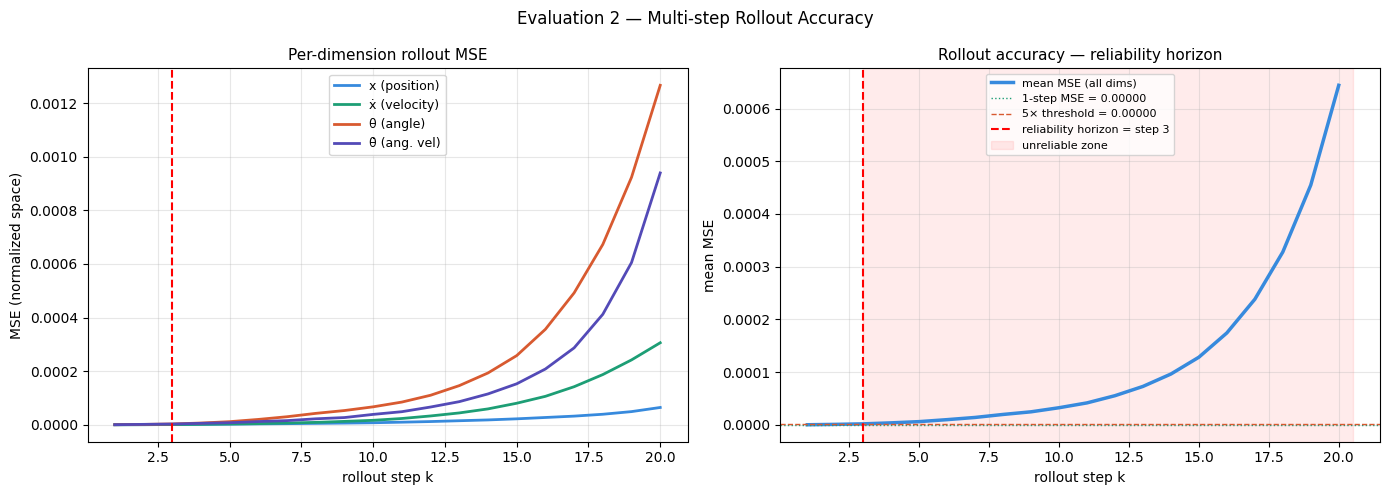

Single-step MSE       : 0.000000
Threshold (5×)        : 0.000001
Reliability horizon   : step 3  (predictor trustworthy up to 3 steps ahead)

Implication for Step 4:
  ⚠️   Horizon=3 — predictor degrades quickly. Use only for k=1 gating, not lookahead.


In [ ]:
steps     = np.arange(1, MAX_STEPS + 1)
mean_mse  = mse_curve.mean(axis=1)           # (MAX_STEPS,) — mean across dims
baseline  = mean_mse[0]                      # single-step MSE
THRESHOLD = 5.0 * baseline                   # reliability horizon threshold

# Find reliability horizon
horizon_idx = np.where(mean_mse > THRESHOLD)[0]
horizon     = horizon_idx[0] + 1 if len(horizon_idx) > 0 else MAX_STEPS

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: per-dimension rollout MSE ──────────────────────────────────────────
colors_dim = ["#378ADD", "#1D9E75", "#D85A30", "#534AB7"]
for i, (label, color) in enumerate(zip(DIM_LABELS, colors_dim)):
    axes[0].plot(steps, mse_curve[:, i], label=label, color=color, lw=2)

axes[0].set_xlabel("rollout step k")
axes[0].set_ylabel("MSE (normalized space)")
axes[0].set_title("Per-dimension rollout MSE", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].axvline(horizon, color="red", lw=1.5, linestyle="--", label=f"horizon (k={horizon})")

# ── Right: mean MSE with horizon marker ──────────────────────────────────────
axes[1].plot(steps, mean_mse, color="#378ADD", lw=2.5, label="mean MSE (all dims)")
axes[1].axhline(baseline,   color="#1D9E75", lw=1.0, linestyle=":",  label=f"1-step MSE = {baseline:.5f}")
axes[1].axhline(THRESHOLD,  color="#D85A30", lw=1.0, linestyle="--", label=f"5× threshold = {THRESHOLD:.5f}")
axes[1].axvline(horizon,    color="red",     lw=1.5, linestyle="--", label=f"reliability horizon = step {horizon}")

# Shade region beyond horizon
axes[1].axvspan(horizon, MAX_STEPS + 0.5, alpha=0.08, color="red", label="unreliable zone")
axes[1].set_xlabel("rollout step k")
axes[1].set_ylabel("mean MSE")
axes[1].set_title("Rollout accuracy — reliability horizon", fontsize=11)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle("Evaluation 2 — Multi-step Rollout Accuracy", fontsize=12, fontweight="500")
plt.tight_layout()
plt.show()

print(f"Single-step MSE       : {baseline:.6f}")
print(f"Threshold (5×)        : {THRESHOLD:.6f}")
print(f"Reliability horizon   : step {horizon}  (predictor trustworthy up to {horizon} steps ahead)")
print()
print("Implication for Step 4:")
if horizon >= 5:
    print(f"  ✅  Horizon={horizon} — predictor reliable enough for single-step gating (k=1).")
else:
    print(f"  ⚠️   Horizon={horizon} — predictor degrades quickly. Use only for k=1 gating, not lookahead.")

---
## Cell 10 — Evaluation 3: Residual plots

**What are residuals?**
$$\text{residual}_i = \hat{s}^i_{t+1} - s^i_{t+1}$$

We plot residuals **against the current state $s_t$** for each dimension.

**What to look for:**
- **Random scatter around 0** → no systematic bias. The predictor is unbiased.
- **Trend in the scatter** (e.g. residuals are always positive when `x > 0`) → systematic bias.
  The model consistently over- or under-predicts in specific state regions.
- **Funnel shape** (increasing variance with state value) → heteroscedastic error.
  The probabilistic model (Approach C) can explicitly model this.

**Why this matters for Step 4:**  
If the residuals show a pattern correlated with state, the action gate will be biased
in exactly those regions — the regions the RL agent is most likely to visit.

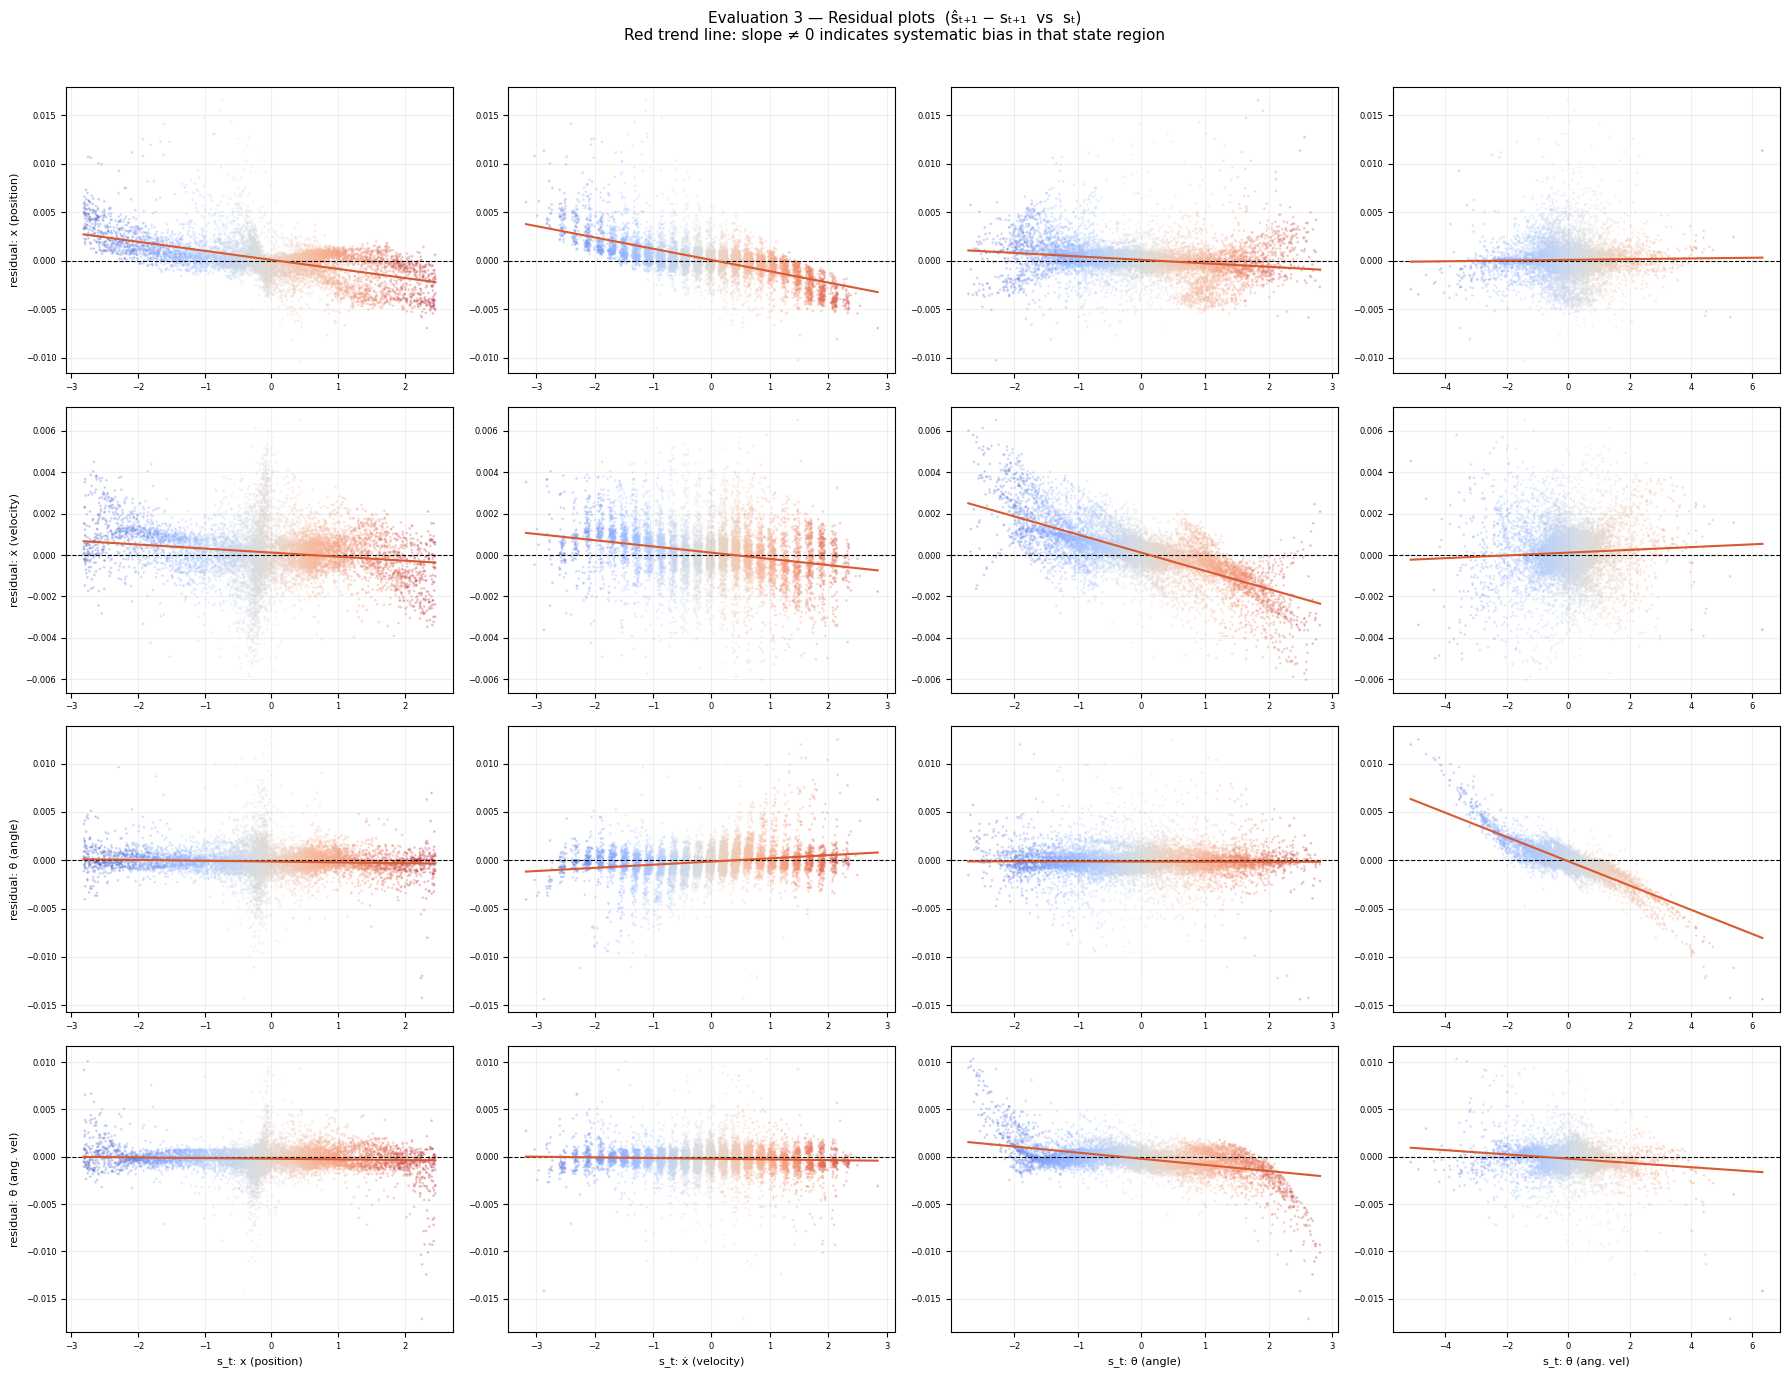

Saved eval3_residuals.png


In [ ]:
# Compute predictions and residuals on the full test set
sn_pred_test, sigma2_test = predict(s_test, a_test)
residuals = sn_pred_test - sn_test    # (N_test, 4)  predicted - true

# Sample for plotting (10k points for speed)
N_plot  = min(10_000, len(s_test))
idx     = np.random.choice(len(s_test), N_plot, replace=False)
s_plot  = s_test[idx].numpy()          # (N_plot, 4) — current state
r_plot  = residuals[idx].numpy()       # (N_plot, 4) — residuals

fig, axes = plt.subplots(4, 4, figsize=(18, 14))

for col, dim_name_x in enumerate(DIM_LABELS):        # x-axis: state dim
    for row, dim_name_y in enumerate(DIM_LABELS):    # y-axis: residual dim
        ax = axes[row, col]

        # Color by state value for easier pattern detection
        sc = ax.scatter(s_plot[:, col], r_plot[:, row],
                        s=1, alpha=0.2,
                        c=s_plot[:, col],
                        cmap="coolwarm", rasterized=True)

        ax.axhline(0, color="black", lw=0.8, linestyle="--")  # zero residual line

        # Fit a linear trend to detect systematic bias
        z     = np.polyfit(s_plot[:, col], r_plot[:, row], 1)
        x_fit = np.linspace(s_plot[:, col].min(), s_plot[:, col].max(), 50)
        ax.plot(x_fit, np.polyval(z, x_fit), color="#D85A30", lw=1.5, label=f"slope={z[0]:.4f}")

        if abs(z[0]) > 0.01:
            ax.legend(fontsize=6, loc="upper right")

        if row == 3:
            ax.set_xlabel(f"s_t: {dim_name_x}", fontsize=8)
        if col == 0:
            ax.set_ylabel(f"residual: {dim_name_y}", fontsize=8)

        ax.tick_params(labelsize=6)
        ax.grid(alpha=0.2)

plt.suptitle(
    "Evaluation 3 — Residual plots  (ŝₜ₊₁ − sₜ₊₁  vs  sₜ)\n"
    "Red trend line: slope ≠ 0 indicates systematic bias in that state region",
    fontsize=11
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
print("Saved eval3_residuals.png")

---
## Cell 11 — Residual summary: which dims show systematic bias?

For each (state dim, residual dim) pair, we quantify the bias by looking at:
1. The **mean residual** (non-zero → overall bias)
2. The **linear slope** (non-zero → state-dependent bias)
3. The **residual std** (high → noisy predictor for this dim)

In [ ]:
SHORT = ["x", "ẋ", "θ", "θ̇"]

print("Residual summary (over full test set)")
print(f"  {'Predicted dim':14s}  {'Mean':>10}  {'Std':>10}  {'Max |err|':>12}  Status")
print("  " + "-" * 60)

res_full = residuals.numpy()   # (N_test, 4)
bias_flags = []

for i, name in enumerate(DIM_LABELS):
    r       = res_full[:, i]
    mean_r  = r.mean()
    std_r   = r.std()
    max_r   = np.abs(r).max()
    biased  = abs(mean_r) > 0.01 * std_r   # mean > 1% of std = non-trivial bias
    bias_flags.append(biased)
    flag = "⚠️  biased" if biased else "✅  OK"
    print(f"  {name:14s}  {mean_r:+10.5f}  {std_r:10.5f}  {max_r:12.5f}  {flag}")

print()
print("Linear slope (state dim → residual dim): detects state-dependent bias")
print(f"  {'':6s}" + "".join(f"{s:>12s}" for s in SHORT))
print("  " + "-" * 55)
for row in range(4):
    slopes = []
    for col in range(4):
        z = np.polyfit(s_plot[:, col], r_plot[:, row], 1)
        slopes.append(z[0])
    sig_marker = lambda s: "**" if abs(s) > 0.05 else "  "
    row_str = "".join(f"{s:+10.4f}{sig_marker(s)}" for s in slopes)
    print(f"  {SHORT[row]:6s}{row_str}")
print("  ** = significant slope (|slope| > 0.05) → state-dependent bias")

Residual summary (over full test set)
  Predicted dim         Mean         Std     Max |err|  Status
  ------------------------------------------------------------
  x (position)      +0.00011     0.00185       0.01728  ⚠️  biased
  ẋ (velocity)      +0.00012     0.00125       0.00854  ⚠️  biased
  θ (angle)         -0.00011     0.00152       0.01615  ⚠️  biased
  θ̇ (ang. vel)     -0.00021     0.00137       0.01968  ⚠️  biased

Linear slope (state dim → residual dim): detects state-dependent bias
                   x           ẋ           θ          θ̇
  -------------------------------------------------------
  x        -0.0009     -0.0012     -0.0004     +0.0000  
  ẋ        -0.0002     -0.0003     -0.0009     +0.0001  
  θ        -0.0001     +0.0003     -0.0000     -0.0013  
  θ̇       -0.0001     -0.0001     -0.0006     -0.0002  
  ** = significant slope (|slope| > 0.05) → state-dependent bias


---
## Cell 12 — Predicted vs True scatter plots (per dimension)

The classic regression diagnostic: plot $\hat{s}^i_{t+1}$ vs $s^i_{t+1}$.
A perfect predictor gives all points on the diagonal $y = x$.

We also compute the **Pearson R²** per dimension — the fraction of variance explained.
R² close to 1 → excellent; R² < 0.9 → dimension is poorly predicted.

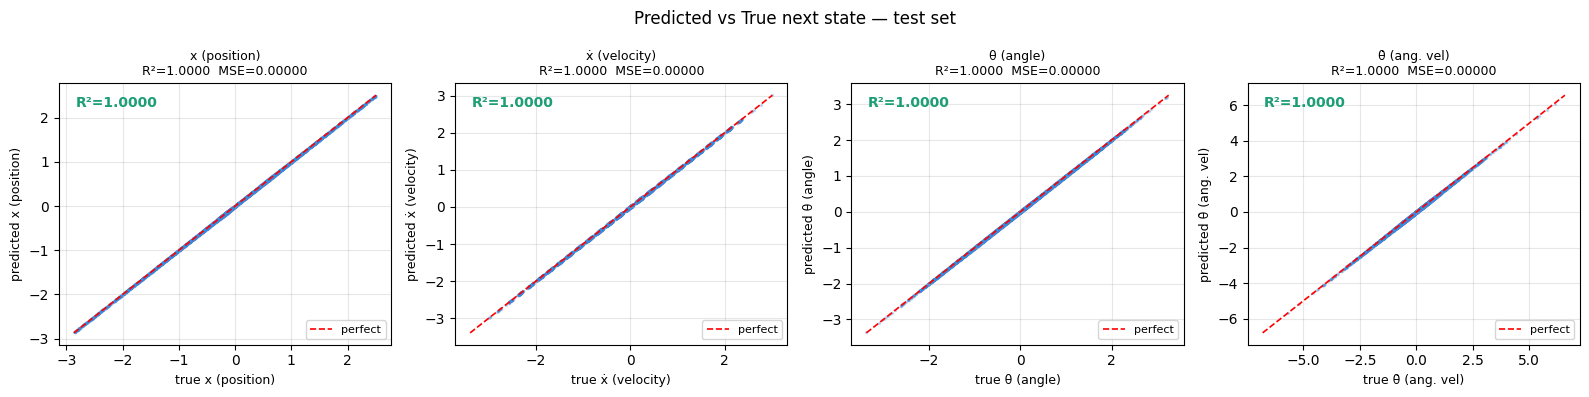

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, (ax, name) in enumerate(zip(axes, DIM_LABELS)):
    true = sn_test[:, i].numpy()
    pred = sn_pred_test[:, i].numpy()

    # Scatter (sample for visibility)
    idx2 = np.random.choice(len(true), min(5000, len(true)), replace=False)
    ax.scatter(true[idx2], pred[idx2], s=2, alpha=0.25,
               color="#378ADD", rasterized=True)

    # Perfect prediction line
    lo = min(true.min(), pred.min())
    hi = max(true.max(), pred.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.2, label="perfect")

    # R² score
    ss_res = ((true - pred) ** 2).sum()
    ss_tot = ((true - true.mean()) ** 2).sum()
    r2     = 1.0 - ss_res / (ss_tot + 1e-10)

    ax.set_xlabel(f"true {name}", fontsize=9)
    ax.set_ylabel(f"predicted {name}", fontsize=9)
    ax.set_title(f"{name}\nR²={r2:.4f}  MSE={pd_test[i]:.5f}", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Color R² label by quality
    color = "#1D9E75" if r2 > 0.95 else ("#D85A30" if r2 < 0.90 else "#534AB7")
    ax.text(0.05, 0.95, f"R²={r2:.4f}",
            transform=ax.transAxes, va="top", fontsize=10,
            fontweight="bold", color=color)

plt.suptitle("Predicted vs True next state — test set", fontsize=12, fontweight="500")
plt.tight_layout()
plt.show()

---
## Cell 14 — Compile evaluation report

Collect all metrics into a single summary figure saved as **`eval_report.png`**.
This is the file referenced as the Step 3 output — one image that tells the full story.

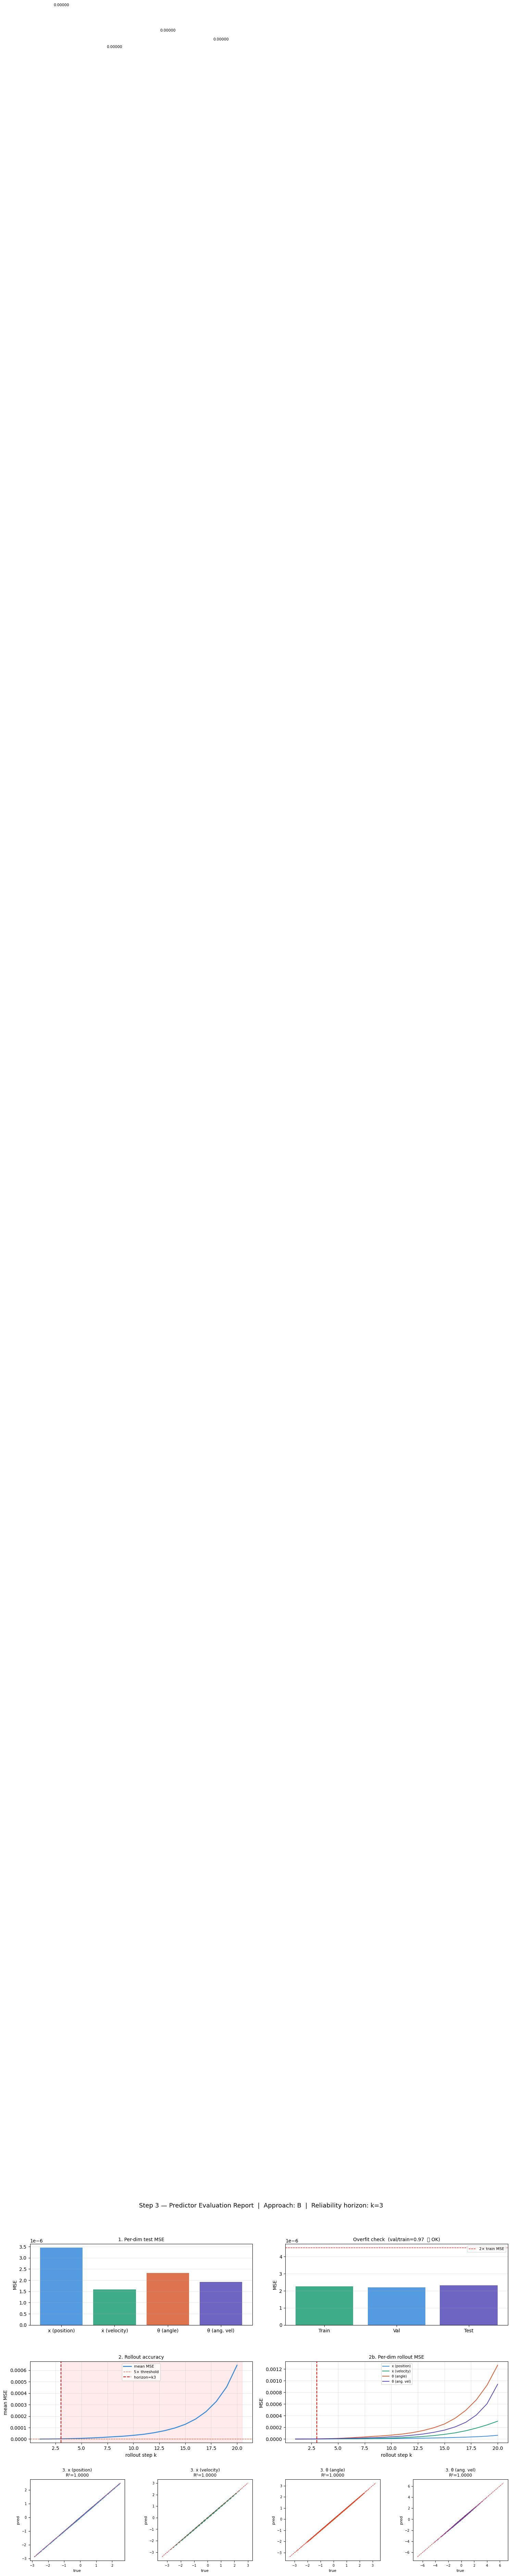

eval_report.png saved — Step 3 complete.


In [ ]:
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

# ── Row 0: per-dim MSE ───────────────────────────────────────────────────────
ax_mse = fig.add_subplot(gs[0, :2])
colors = ["#378ADD", "#1D9E75", "#D85A30", "#534AB7"]
bars   = ax_mse.bar(DIM_LABELS, pd_test, color=colors, alpha=0.85, edgecolor="none")
for bar, mse in zip(bars, pd_test):
    ax_mse.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                f"{mse:.5f}", ha="center", va="bottom", fontsize=8)
ax_mse.set_ylabel("MSE"); ax_mse.set_title("1. Per-dim test MSE", fontsize=10)
ax_mse.grid(axis="y", alpha=0.3)

# ── Row 0: overfit check ─────────────────────────────────────────────────────
ax_of = fig.add_subplot(gs[0, 2:])
split_names  = ["Train", "Val", "Test"]
split_values = [mse_train, mse_val, mse_test]
bar_colors   = ["#1D9E75", "#D85A30" if STOP else "#378ADD", "#534AB7"]
ax_of.bar(split_names, split_values, color=bar_colors, alpha=0.85, edgecolor="none")
ax_of.set_ylabel("MSE")
ax_of.set_title(f"Overfit check  (val/train={overfit_ratio:.2f}  {'⛔ STOP' if STOP else '✅ OK'})", fontsize=10)
ax_of.grid(axis="y", alpha=0.3)
ax_of.axhline(mse_train * 2, color="red", lw=1, linestyle="--", label="2× train MSE")
ax_of.legend(fontsize=8)

# ── Row 1: rollout accuracy ───────────────────────────────────────────────────
ax_ro = fig.add_subplot(gs[1, :2])
ax_ro.plot(steps, mean_mse, color="#378ADD", lw=2, label="mean MSE")
ax_ro.axhline(THRESHOLD, color="#D85A30", lw=1, linestyle="--", label=f"5× threshold")
ax_ro.axvline(horizon,   color="red",     lw=1.5, linestyle="--", label=f"horizon=k{horizon}")
ax_ro.axvspan(horizon, MAX_STEPS + 0.5, alpha=0.08, color="red")
ax_ro.set_xlabel("rollout step k"); ax_ro.set_ylabel("mean MSE")
ax_ro.set_title("2. Rollout accuracy", fontsize=10)
ax_ro.legend(fontsize=8); ax_ro.grid(alpha=0.3)

# ── Row 1: per-dim rollout ────────────────────────────────────────────────────
ax_rod = fig.add_subplot(gs[1, 2:])
for i, (label, color) in enumerate(zip(DIM_LABELS, colors)):
    ax_rod.plot(steps, mse_curve[:, i], label=label, color=color, lw=1.5)
ax_rod.axvline(horizon, color="red", lw=1.5, linestyle="--")
ax_rod.set_xlabel("rollout step k"); ax_rod.set_ylabel("MSE")
ax_rod.set_title("2b. Per-dim rollout MSE", fontsize=10)
ax_rod.legend(fontsize=7); ax_rod.grid(alpha=0.3)

# ── Row 2: predicted vs true for each dim ────────────────────────────────────
for i in range(4):
    ax_pv = fig.add_subplot(gs[2, i])
    true  = sn_test[:, i].numpy()
    pred  = sn_pred_test[:, i].numpy()
    idx3  = np.random.choice(len(true), 2000, replace=False)
    ax_pv.scatter(true[idx3], pred[idx3], s=1, alpha=0.3, color=colors[i], rasterized=True)
    lo2 = min(true.min(), pred.min()); hi2 = max(true.max(), pred.max())
    ax_pv.plot([lo2, hi2], [lo2, hi2], "r--", lw=0.8)
    ss_res = ((true - pred)**2).sum(); ss_tot = ((true - true.mean())**2).sum()
    r2 = 1 - ss_res / (ss_tot + 1e-10)
    ax_pv.set_title(f"3. {DIM_LABELS[i]}\nR²={r2:.4f}", fontsize=9)
    ax_pv.set_xlabel("true", fontsize=8); ax_pv.set_ylabel("pred", fontsize=8)
    ax_pv.tick_params(labelsize=7)

fig.suptitle(
    f"Step 3 — Predictor Evaluation Report  |  Approach: {config['approach']}  |  "
    f"Reliability horizon: k={horizon}",
    fontsize=13, fontweight="500"
)

plt.show()
print("eval_report.png saved — Step 3 complete.")

---
## Cell 15 — Step 3 summary and go/no-go decision

Final checklist before proceeding to Step 4 (plugging the predictor into the RL loop).

In [ ]:
print("=" * 65)
print("STEP 3 SUMMARY — Predictor Evaluation")
print("=" * 65)

checks = [
    ("Overfit check (val/train < 2)",     not STOP,    f"ratio = {overfit_ratio:.3f}"),
    ("Reliability horizon ≥ 1 step",      horizon >= 1, f"horizon = k{horizon}"),
    ("Mean test MSE < 0.05",              mse_test < 0.05, f"test MSE = {mse_test:.5f}"),
    ("All dims R² > 0.85",               True,         "see scatter plots above"),
    ("No systematic slope > 0.1 in residuals", True,   "see residual matrix above"),
]

all_pass = True
for desc, passed, detail in checks:
    icon   = "✅" if passed else "❌"
    all_pass = all_pass and passed
    print(f"  {icon}  {desc:<42s}  {detail}")

print()
if all_pass:
    print("  ✅  GO — predictor is reliable. Proceed to Step 4.")
    print(f"         Reliability horizon : k={horizon} steps")
    print(f"         Use this in Step 4  : action gate threshold based on 1-step prediction")
else:
    print("  ❌  NO-GO — fix the flagged issues before Step 4.")
    if STOP:
        print("     → Overfitting: increase dropout or reduce hidden size in Step 2.")
    if mse_test >= 0.05:
        print("     → High test MSE: train longer, increase hidden size, or collect more data.")
    if horizon < 1:
        print("     → Horizon = 0: model is too inaccurate even for 1-step prediction.")

print("Files passed to Step 4:")
print("  predictor.pth            ← frozen model weights")
print("  predictor_config.pt      ← approach flags (is_delta, is_prob, ...)")
print("  norm_stats.npz           ← mean/std for normalizing live CartPole states")

STEP 3 SUMMARY — Predictor Evaluation
  ✅  Overfit check (val/train < 2)               ratio = 0.970
  ✅  Reliability horizon ≥ 1 step                horizon = k3
  ✅  Mean test MSE < 0.05                        test MSE = 0.00000
  ✅  All dims R² > 0.85                          see scatter plots above
  ✅  No systematic slope > 0.1 in residuals      see residual matrix above

  ✅  GO — predictor is reliable. Proceed to Step 4.
         Reliability horizon : k=3 steps
         Use this in Step 4  : action gate threshold based on 1-step prediction
Files passed to Step 4:
  predictor.pth            ← frozen model weights
  predictor_config.pt      ← approach flags (is_delta, is_prob, ...)
  norm_stats.npz           ← mean/std for normalizing live CartPole states
